<a href="https://colab.research.google.com/github/ujjwalroyal14/BlurDetection/blob/main/NeuralNetworkExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from torch import nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.metrics import confusion_matrix,classification_report

In [92]:
#loading the dataset
data=load_breast_cancer()
x=data['data']
y=data['target']

In [93]:
print(f"size x:{x.shape}")
print(f"size y:{x.shape}")

size x:(569, 30)
size y:(569, 30)


In [94]:
#creating the training/test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42) #include 20 percent data set

In [95]:
#checking the shape of the training dataset
x_train.shape,y_train.shape

((455, 30), (455,))

In [96]:
#checking the shape of the test dataset
x_test.shape,y_test.shape

((114, 30), (114,))

In [97]:
#applying the normalization to the training dataset
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [98]:
class Hyperparameters():
  def __init__(self):
    self.number_of_epochs=50
    self.batch_size=8
    self.learning_rate=0.01
    self.shuffle=True

In [99]:
#train data
class TrainData(Dataset):

  def __init__(self,x_train,y_train):

    self.x_train=torch.tensor(x_train,dtype=torch.float32)
    self.y_train=torch.tensor(y_train,dtype=torch.float32)

  def __getitem__(self, index):
    return self.x_train[index], self.y_train[index]

  def __len__ (self):
    return len(self.x_train)

train_data = TrainData(x_train, y_train)



In [100]:
#test data
class TestData(Dataset):

  def __init__(self,x_test):
    self.x_test=torch.tensor(x_test,dtype=torch.float32)

  def __getitem__(self, index):
    return self.x_test[index]

  def __len__ (self):
    return len(self.x_test)

test_data = TestData(x_test)

In [101]:
#declaring the train and the test dataset loaders
hyperparameters=Hyperparameters()
train_loader = DataLoader(dataset=train_data,batch_size=hyperparameters.batch_size, shuffle=hyperparameters.shuffle)

test_loader=DataLoader(dataset=test_data, batch_size=1)


In [102]:
#define the model
class BreastCancerClassifier(nn.Module):
  #30 -> 64 -> relu -> 128 -> relu ->1 -> sigmoid
  def __init__(self,input_shape):
    super(BreastCancerClassifier, self).__init__()
    self.fc1=nn.Linear(input_shape,64)
    self.fc2=nn.Linear(64,128)
    self.fc3=nn.Linear(128,1)
  def forward(self,x):
    x=torch.relu(self.fc1(x))
    x=torch.relu(self.fc2(x))
    x=torch.sigmoid(self.fc3(x))
    return x

In [103]:
#checking the GPU
!nvidia-smi

Sat May  3 06:58:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             35W /   70W |     158MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [104]:
device=torch.device("cuda" if torch.cuda.is_available()else "cpu")
print(device)

cuda


In [105]:
model=BreastCancerClassifier(input_shape=x_train.shape[1]) # declaring the model
optimizer=optim.Adam(model.parameters(), lr=hyperparameters.learning_rate) # declaring the optimizer
criterion=nn.BCELoss() #declaring the loss function
model.to(device) # moving the model to the device

BreastCancerClassifier(
  (fc1): Linear(in_features=30, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)

In [106]:
def binary_acc(y_pred, y): #this function is responsible for calculating the accuracies for a given batch
  results=torch.round(y_pred)
  correct_results_sum= (results == y).sum().float()
  acc=correct_results_sum/y.shape[0]
  acc=torch.round(acc * 100)
  return acc

In [107]:
#training the model
losses=[]
accuracies=[]
model.train() # putting the model in train mode
for i in range(1,hyperparameters.number_of_epochs+1):

  epoch_loss=0
  epoch_accuracy=0

  for data in train_loader:

    x_train,y_train=data

    x_train=x_train.to(device) #moving the input feature to device(cuda)
    y_train=y_train.to(device) #moving the target variable to device(cuda)

    optimizer.zero_grad() #zeroing the gradients so that they don't accumulte over the next batch

    y_pred=model(x_train) # getting the predictions from the model

    loss=criterion(y_pred, y_train.reshape(-1,1)) #computing the loss for the current batch
    acc=binary_acc(y_pred, y_train.reshape(-1,1)) #computing the accuracy for the current batch

    loss.backward() #calculating the gradient
    optimizer.step() #updating the weights

    epoch_loss += loss.item() #Adding the loss for a single batch to the total epoch_loss
    epoch_accuracy += acc.item() ##Adding the accuracy for a single batch to the total epoch_accuracy

  if i % 5 == 0:
    print(f'Epoch {i+0:03}: | Loss: {epoch_loss/len(train_loader):.5f} | Acc: {epoch_accuracy/len(train_loader):.3f}')
    losses.append(epoch_loss/len(train_loader)) #recording the losses after every 5 epoch
    accuracies.append(epoch_accuracy/len(train_loader)) # recording the accuracies after every 5 epoch


Epoch 005: | Loss: 0.08034 | Acc: 97.246
Epoch 010: | Loss: 0.01808 | Acc: 99.368
Epoch 015: | Loss: 0.00782 | Acc: 99.579
Epoch 020: | Loss: 0.01122 | Acc: 99.789
Epoch 025: | Loss: 0.00135 | Acc: 100.000
Epoch 030: | Loss: 0.00462 | Acc: 99.789
Epoch 035: | Loss: 0.21974 | Acc: 99.789
Epoch 040: | Loss: 0.21943 | Acc: 99.789
Epoch 045: | Loss: 0.21934 | Acc: 99.789
Epoch 050: | Loss: 0.21932 | Acc: 99.789


Text(0, 0.5, 'Loss')

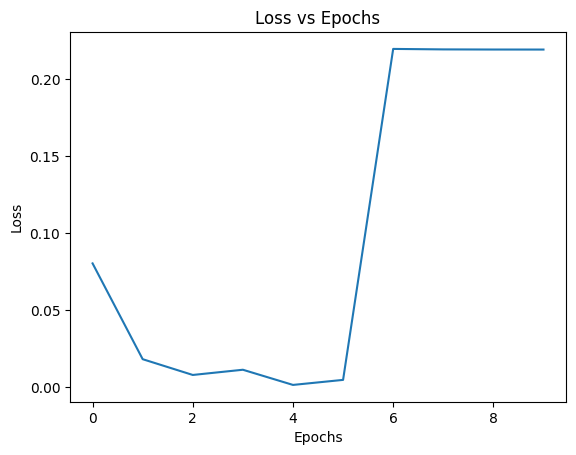

In [108]:
#plotting the loss
plt.plot(losses)
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

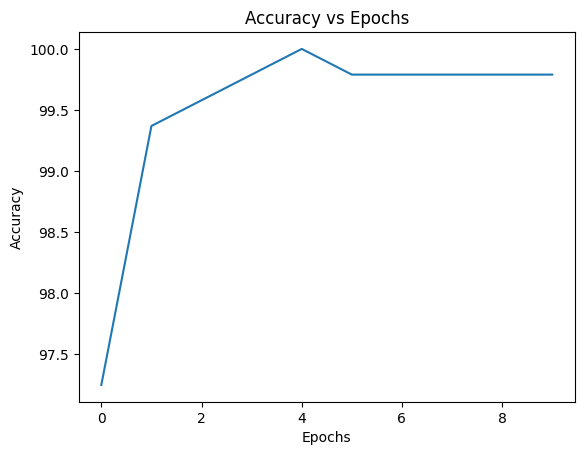

In [109]:
#printing the accuracy
plt.plot(accuracies)
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

In [111]:
y_test_pred=[]
model.eval() #putting the model in evaluation mode
with torch.no_grad():
  for x_test in test_loader:
      x_test=x_test.to(device) #moving the test dataset batch to the device(cuda)

      y_test_probabilities=model(x_test) # getting the predictions from the model (probabilties after apply)
      y_pred_labels=torch.round(y_test_probabilities)

      y_test_pred.append(y_pred_labels.cpu().numpy()) # moving the result from GPU to CPU

y_test_pred=[a.squeeze().tolist() for a in y_test_pred] #doing postprocessing to get the actual labels

In [112]:
confusion_matrix(y_test,y_test_pred) # making the confusion matrix

array([[41,  2],
       [ 3, 68]])

In [114]:
print(classification_report(y_test,y_test_pred)) # printing the classification report

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

